# Task 6 — End-to-End Housing Price Predictor

**Goal:** predict the median house value of a California district from census features, using
**Decision Trees and Random Forests** inside a full pipeline with **feature scaling**.

**Pipeline:** load → explore → clean → split → preprocess (impute + scale + one-hot) → train → evaluate → tune lightly → save.

Dataset: California Housing (1990 census), 20,640 districts — `data/housing.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
os.makedirs("outputs", exist_ok=True)
os.makedirs("model", exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Load and explore the data

In [2]:
df = pd.read_csv("data/housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
# Missing values: only total_bedrooms has some (207 rows) -> we will impute with the median
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


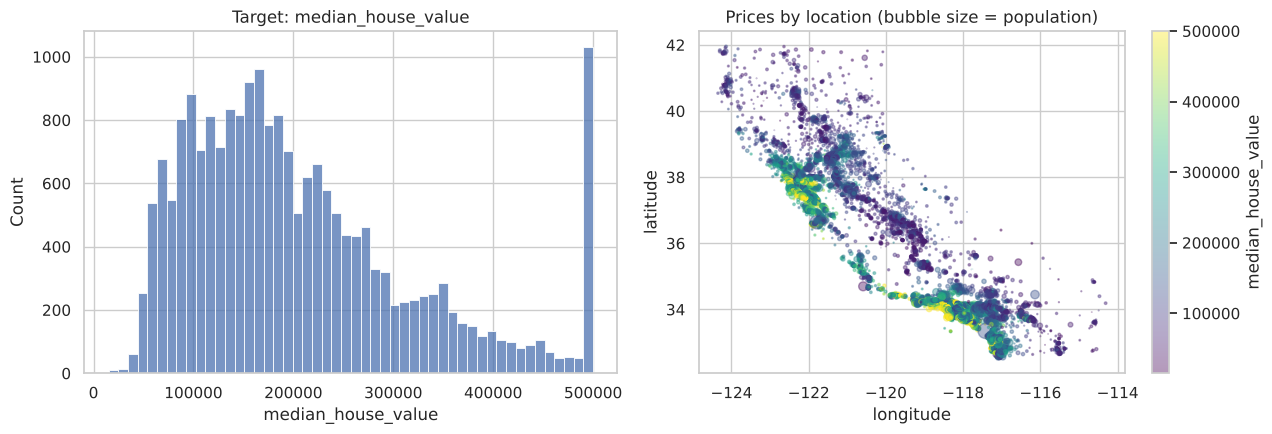

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["median_house_value"], bins=50, ax=axes[0])
axes[0].set_title("Target: median_house_value")
sc = axes[1].scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                     s=df["population"] / 300, cmap="viridis", alpha=0.4)
plt.colorbar(sc, ax=axes[1], label="median_house_value")
axes[1].set_title("Prices by location (bubble size = population)")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
plt.tight_layout(); plt.savefig("outputs/eda.png", dpi=120); plt.show()

**Observations**
- The target is capped at **$500,001** (the spike on the right). The model can never predict above it.
- Coastal areas (Bay Area, LA) are the most expensive, so latitude/longitude and `ocean_proximity` matter.

In [7]:
corr = df.select_dtypes("number").corr()["median_house_value"].sort_values(ascending=False)
corr

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

`median_income` is by far the strongest single predictor (correlation ≈ 0.69).

## 2. Train / test split

In [8]:
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("train:", X_train.shape, " test:", X_test.shape)

train: (16512, 9)  test: (4128, 9)


## 3. Preprocessing pipeline (feature scaling)

- **Numeric columns:** fill missing values with the median → `StandardScaler` (mean 0, std 1).
- **Categorical column** `ocean_proximity`: one-hot encode.

Everything lives inside one scikit-learn `Pipeline`, so the exact same steps run on training data, test data,
and later on the live API/dashboard inputs — no data leakage and no manual preprocessing at prediction time.

> Note: tree models don't strictly *need* scaling (splits are threshold-based), but the task asks for it and it
> makes the pipeline reusable with scale-sensitive models — we include Linear Regression as a baseline to show this.

In [9]:
NUM_COLS = ["longitude", "latitude", "housing_median_age", "total_rooms",
            "total_bedrooms", "population", "households", "median_income"]
CAT_COLS = ["ocean_proximity"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])

def make_pipeline(model):
    return Pipeline([("preprocess", preprocessor), ("model", model)])

## 4. Train and compare models

In [10]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

candidates = {
    "Linear Regression (baseline)": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
}

results = pd.DataFrame([evaluate(n, make_pipeline(m)) for n, m in candidates.items()]).set_index("model")
results.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.3f}"})

,RMSE,MAE,R2
model,,,
Linear Regression (baseline),"70,059","50,670",0.625
Decision Tree,"69,176","43,604",0.635
Decision Tree (max_depth=10),"61,280","40,556",0.713
Random Forest,"48,942","31,628",0.817


**Reading the results**
- The **unrestricted Decision Tree overfits**: it memorises the training set and generalises poorly.
- Limiting depth helps, but the **Random Forest** (an ensemble of 100 trees on bootstrapped samples, averaging their
  votes) cuts the error substantially — averaging many decorrelated trees reduces variance.

## 5. Light tuning + cross-validation of the Random Forest

In [11]:
# A few sensible settings, checked with 5-fold cross-validation on the training set only.
# (The saved model stays ~30 MB, which is fine for GitHub.)
settings = [
    {"n_estimators": 100, "min_samples_leaf": 1, "max_features": 1.0},
    {"n_estimators": 100, "min_samples_leaf": 3, "max_features": 0.5},
    {"n_estimators": 150, "min_samples_leaf": 3, "max_features": 0.5},
]
cv_rows = []
for s in settings:
    pipe = make_pipeline(RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, **s))
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    cv_rows.append({**s, "CV RMSE (mean)": -scores.mean(), "CV RMSE (std)": scores.std()})
cv_df = pd.DataFrame(cv_rows)
cv_df.style.format({"CV RMSE (mean)": "{:,.0f}", "CV RMSE (std)": "{:,.0f}"})

,n_estimators,min_samples_leaf,max_features,CV RMSE (mean),CV RMSE (std)
0,100,1,1.000000,"49,262",624
1,100,3,0.500000,"49,462",588
2,150,3,0.500000,"49,283",563


In [12]:
best = cv_df.loc[cv_df["CV RMSE (mean)"].idxmin()]
best_params = {"n_estimators": int(best.n_estimators),
               "min_samples_leaf": int(best.min_samples_leaf),
               "max_features": float(best.max_features)}
print("Best settings:", best_params)

final_pipe = make_pipeline(RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, **best_params))
final_pipe.fit(X_train, y_train)
pred = final_pipe.predict(X_test)

final_metrics = {
    "RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
    "MAE": float(mean_absolute_error(y_test, pred)),
    "R2": float(r2_score(y_test, pred)),
}
print({k: round(v, 3) for k, v in final_metrics.items()})

Best settings: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 1.0}


{'RMSE': 48941.7, 'MAE': 31628.407, 'R2': 0.817}


## 6. Evaluate the final model

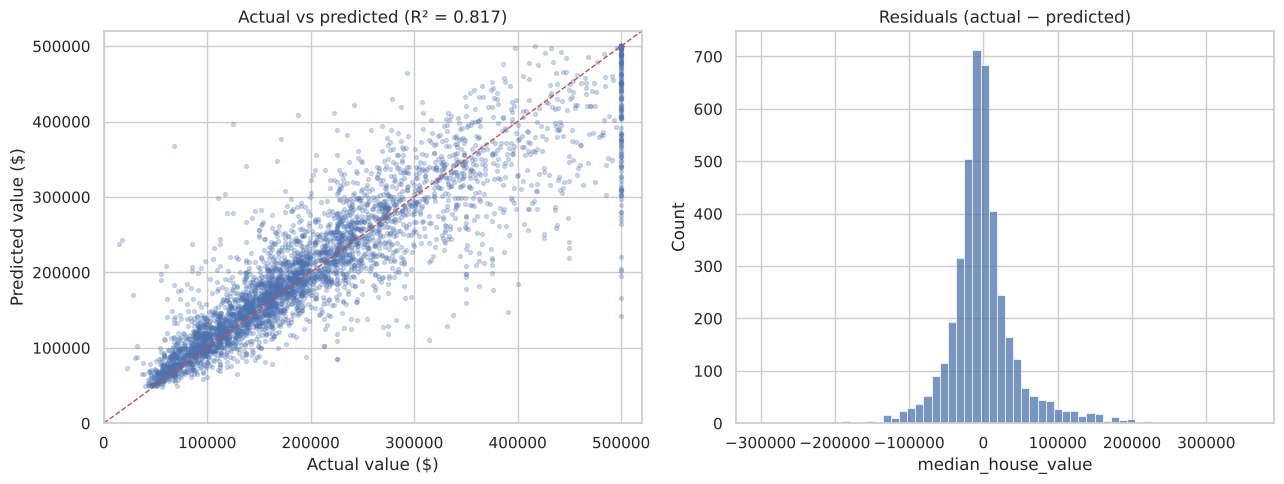

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred, alpha=0.25, s=8)
lims = [0, 520_000]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual value ($)"); axes[0].set_ylabel("Predicted value ($)")
axes[0].set_title(f"Actual vs predicted (R² = {final_metrics['R2']:.3f})")

residuals = y_test - pred
sns.histplot(residuals, bins=60, ax=axes[1])
axes[1].set_title("Residuals (actual − predicted)")
plt.tight_layout(); plt.savefig("outputs/actual_vs_predicted.png", dpi=120); plt.show()

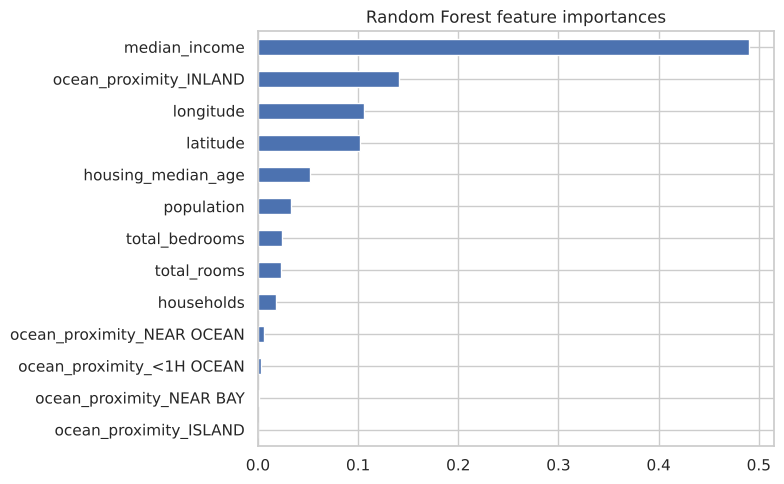

median_income             0.490642
ocean_proximity_INLAND    0.140925
longitude                 0.105889
latitude                  0.101597
housing_median_age        0.051935
population                0.032573
dtype: float64

In [14]:
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(final_pipe.named_steps["model"].feature_importances_, index=feature_names)
importances.index = importances.index.str.replace("num__", "").str.replace("cat__", "")
importances = importances.sort_values()

plt.figure(figsize=(8, 5))
importances.plot.barh()
plt.title("Random Forest feature importances")
plt.tight_layout(); plt.savefig("outputs/feature_importance.png", dpi=120); plt.show()
importances.sort_values(ascending=False).head(6)

**Interpretation:** `median_income` dominates, followed by location (`INLAND` flag, longitude, latitude).
This matches the EDA: richer and coastal districts cost more.

## 7. Save the trained pipeline (used by Task 4 API and Task 5 dashboard)

In [15]:
import json, sklearn

joblib.dump(final_pipe, "model/housing_model.joblib", compress=3)
metadata = {
    "model": "RandomForestRegressor inside a scikit-learn Pipeline (impute + StandardScaler + OneHotEncoder)",
    "sklearn_version": sklearn.__version__,
    "params": best_params,
    "test_metrics": final_metrics,
    "features": NUM_COLS + CAT_COLS,
    "ocean_proximity_values": sorted(df["ocean_proximity"].unique().tolist()),
    "feature_importances": importances.sort_values(ascending=False).round(4).to_dict(),
}
with open("model/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved model: %.1f MB" % (os.path.getsize("model/housing_model.joblib") / 1e6))

Saved model: 30.4 MB


In [16]:
# Sanity check: reload and predict on one raw example, exactly as the API will
reloaded = joblib.load("model/housing_model.joblib")
example = pd.DataFrame([{
    "longitude": -122.23, "latitude": 37.88, "housing_median_age": 41, "total_rooms": 880,
    "total_bedrooms": 129, "population": 322, "households": 126, "median_income": 8.3252,
    "ocean_proximity": "NEAR BAY",
}])
print(f"Predicted: ${reloaded.predict(example)[0]:,.0f}   (actual in dataset: $452,600)")

Predicted: $431,942   (actual in dataset: $452,600)


## Summary
- Full pipeline: **median imputation → StandardScaler → one-hot encoding → Random Forest**, all in one `Pipeline`.
- Random Forest clearly beats a single Decision Tree and the linear baseline (see the comparison table).
- Main limitation: the dataset caps prices at $500,001, so the model under-predicts the most expensive districts.